# Lab 3 Part 2: Customer Churn Prediction

## Step 1: Set-Up + Load and Explore the Data

In [55]:
# Set-Up
"""
Breast Customer churn prediction with KNN
Author: Carlos Martinez Boto
Description: Predict customer churn for a telecommunications company (customers stop using a company's services).
Predicting churn helps companies take proactive measures to retain customers.
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [56]:
# Import the Telco Customer Churn dataset, Load it into a pandas DataFrame
df = pd.read_csv('data_telco/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_orig = df.copy()

# Explore the dataset: shape, columns, data types, missing values
print(f"Dataset loaded successfully!")
print(f"\nShape: {df.shape}\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nMissing values and data types:")
print(df.info())

Dataset loaded successfully!

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL          

In [57]:
# Check the target distribution (how many churned vs. didn't churn)
print("\nTarget distribution (churned):")
print(f"Yes: {(df['Churn'] == 'Yes').sum()}")
print(f"No: {(df['Churn'] == 'No').sum()}")


Target distribution (churned):
Yes: 1869
No: 5174



FEATURE DISTRIBUTIONS
Saved visualization to 'feature_distributions_telco.png'


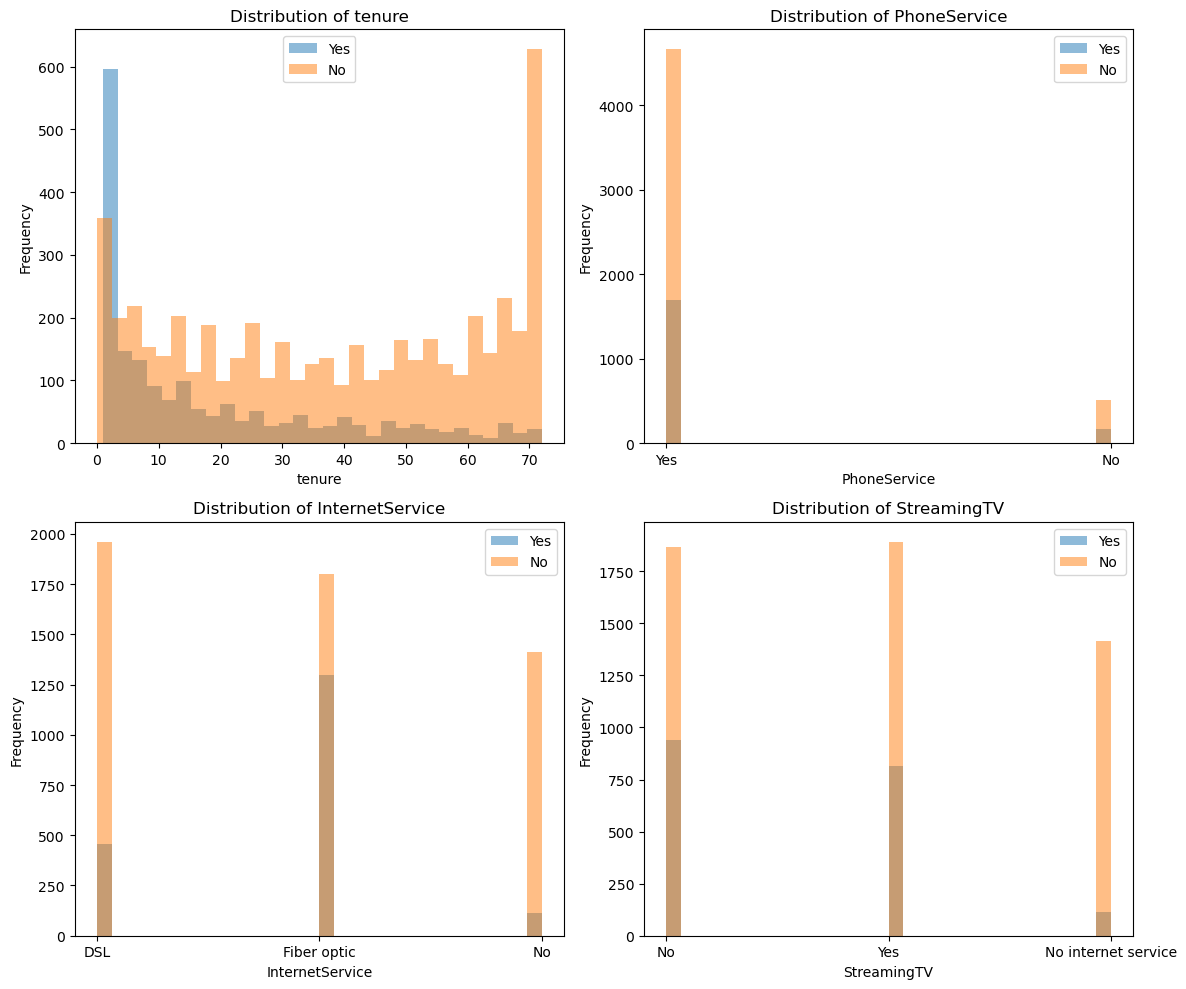

In [58]:
# Visualize some key features
print("\n" + "="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)
 
# Select a few representative features to visualize
key_features = ['tenure', 'PhoneService', 'InternetService', 'StreamingTV']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    axes[idx].hist(df[df['Churn'] == 'Yes'][feature], alpha=0.5, label='Yes', bins=30)
    axes[idx].hist(df[df['Churn'] == 'No'][feature], alpha=0.5, label='No', bins=30)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].legend()
 
plt.tight_layout()
plt.savefig('feature_distributions_telco.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'feature_distributions_telco.png'")
plt.show()

## Step 2: Data Preprocessing

In [59]:
# Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
#           'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
#           'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
#           'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

# Handle missing values (if any)
print("✓ No missing values found!")
print("No need for handling mising values")

✓ No missing values found!
No need for handling mising values


In [60]:
# Convert categorical variables to numeric (use encoding techniques)
df = pd.get_dummies(df, columns=['gender', 'Partner', 'Dependents', 'PhoneService',
                                 'MultipleLines', 'InternetService', 'OnlineSecurity',
                                 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                                 'StreamingTV', 'StreamingMovies', 'Contract',
                                 'PaperlessBilling', 'PaymentMethod', 'Churn'],
                                 drop_first=True, dtype=int)

df = df.select_dtypes(include=[np.number]) # Keep everything that is a number

In [61]:
# Select relevant features for modeling
X_temp = df.drop('Churn_Yes', axis=1) # X --> Variables (remove Churn) / Y --> Output (Churn)

# Removing constant columns
selector = VarianceThreshold(threshold=0.0)
selector.fit(X_temp)
selected_features = X_temp.columns[selector.get_support()]

df = df[list(selected_features) + ['Churn_Yes']] # Put back the variance and y together

# Remove correlated columns
correlation_matrix = df.drop('Churn_Yes', axis=1).corr().abs() # Calculating correlation
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)]
df = df.drop(columns=high_corr_features)

In [62]:
# Separate features (X) from target (y)
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

## Step 3: Split the data

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Step 4: KNN Model

In [64]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
 
print("KNN classifier trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")

KNN classifier trained successfully!
Number of neighbors (k): 5


## Step 5: Make Predictions and Evaluate

In [65]:
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

print(f"Training predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")

Training predictions: 5634
Test predictions: 1409


In [66]:
# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
 
print("=== Model Performance ===")
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nTest Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

=== Model Performance ===

Training Accuracy: 0.8390 (83.90%)
Test Accuracy: 0.7644 (76.44%)

Test Precision: 0.5603
Test Recall: 0.5214


In [67]:
print("\n=== Confusion Matrix ===")
print("               Predicted")
print("               No      Yes")
print(f"Actual No     {test_confusion[0,0]:4d}    {test_confusion[0,1]:4d}")
print(f"       Yes    {test_confusion[1,0]:4d}    {test_confusion[1,1]:4d}")
 
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=["No", "Yes"]))


=== Confusion Matrix ===
               Predicted
               No      Yes
Actual No      882     153
       Yes     179     195

=== Classification Report ===
              precision    recall  f1-score   support

          No       0.83      0.85      0.84      1035
         Yes       0.56      0.52      0.54       374

    accuracy                           0.76      1409
   macro avg       0.70      0.69      0.69      1409
weighted avg       0.76      0.76      0.76      1409



## Step 6: Experiment and Improve

In [68]:
all_recalls = []

k_range = range(1,16,2)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    test_recall = recall_score(y_test, y_test_pred) 
    
    print(f"=== Number of neighbors (k): {knn.n_neighbors} ===")
    print(f"Test Recall: {test_recall:.4f}\n")
    
    all_recalls.append(test_recall)

=== Number of neighbors (k): 1 ===
Test Recall: 0.5267

=== Number of neighbors (k): 3 ===
Test Recall: 0.5241

=== Number of neighbors (k): 5 ===
Test Recall: 0.5214

=== Number of neighbors (k): 7 ===
Test Recall: 0.5294

=== Number of neighbors (k): 9 ===
Test Recall: 0.4893

=== Number of neighbors (k): 11 ===
Test Recall: 0.4813

=== Number of neighbors (k): 13 ===
Test Recall: 0.4947

=== Number of neighbors (k): 15 ===
Test Recall: 0.4920



=== k with the maximum recall: 7 ===


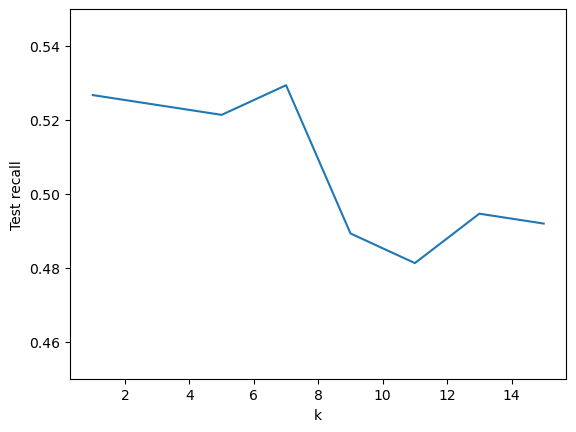

In [69]:
index_max_rec = all_recalls.index(max(all_recalls))
k_max_rec = k_range[index_max_rec]
print(f"=== k with the maximum recall: {k_max_rec} ===")

plt.plot(k_range, all_recalls)

# Labels
plt.xlabel("k")
plt.ylabel("Test recall")

# Set y-axis range
plt.ylim(0.45, 0.55)

# Show plot
plt.show()

## Step 7: Analysis and Recommendations

In [73]:
print(list(df_orig.columns))

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']



FEATURE DISTRIBUTIONS
Saved visualization to 'feature_distributions_telco.png'


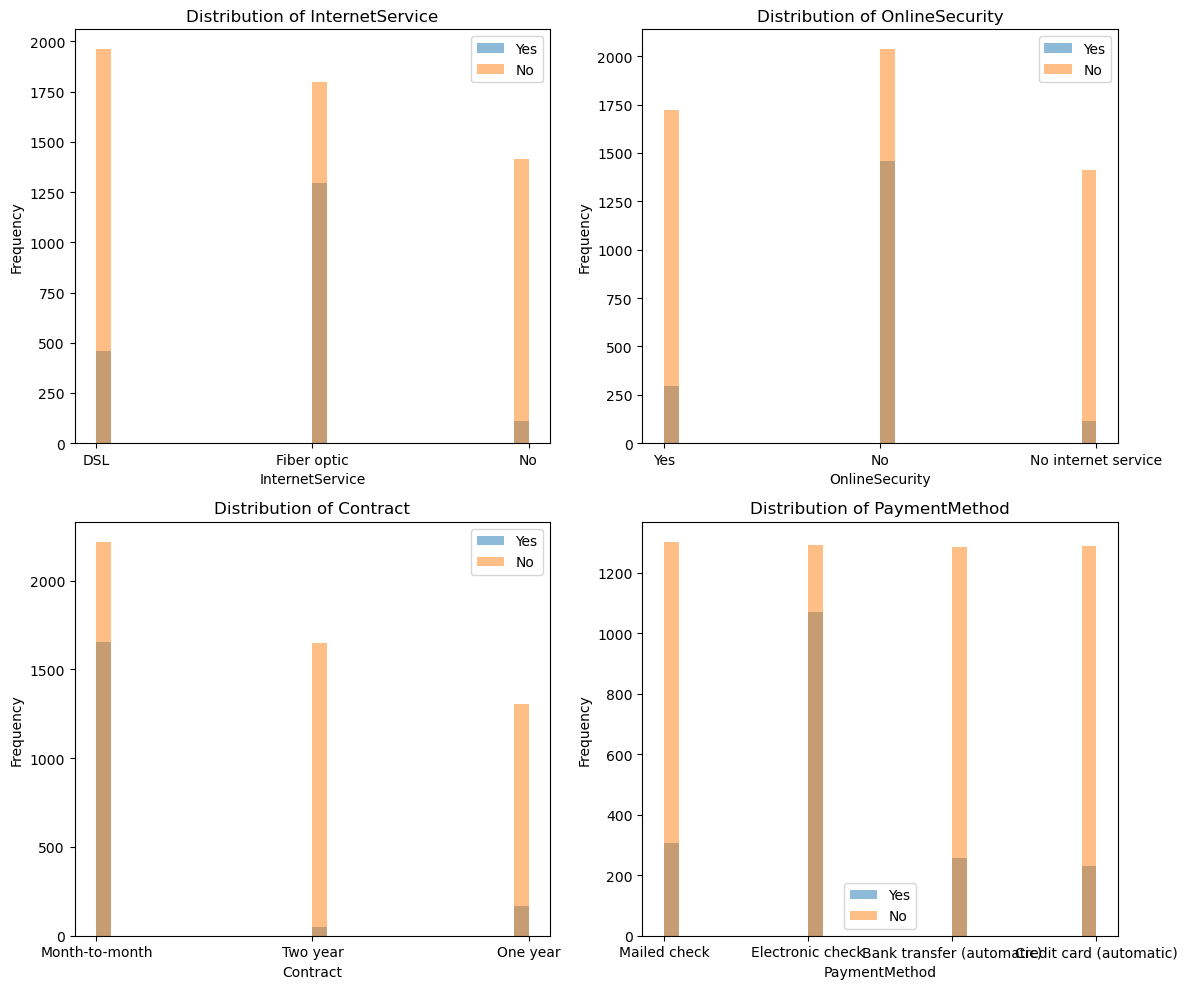

In [80]:
# Visualize some key features
print("\n" + "="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)
 
# Select a few representative features to visualize

# key_features = ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract', 'PaymentMethod']
key_features = ['InternetService', 'OnlineSecurity', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    axes[idx].hist(df_orig[df_orig['Churn'] == 'Yes'][feature], alpha=0.5, label='Yes', bins=30)
    axes[idx].hist(df_orig[df_orig['Churn'] == 'No'][feature], alpha=0.5, label='No', bins=30)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].legend()
 
plt.tight_layout()
plt.savefig('feature_distributions_telco.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'feature_distributions_telco.png'")
plt.show()